# MedBoard — Train GeoSample U-Net Segmentation Model

**Run this notebook in Google Colab to train the GeoSample U-Net.**

GeoSample replaces standard 3×3 convolutions and MaxPooling with:
- **Geometry-guided oriented sampling** — probes aligned to tumor boundaries
- **Differential tokens** — explicit gradient and curvature cues
- **Edge-preserving downsampling** — dual-path pooling that retains boundary signals
- **Consensus skip connections** — geometric alignment between encoder and decoder

What this notebook does:
1. Set up the environment (mount Drive, clone repo, copy data)
2. Load BRISC 2025 segmentation dataset
3. Build the GeoSample U-Net
4. Train with Dice+BCE loss and early stopping
5. Save best weights to Google Drive
6. Plot training curves
7. Evaluate on test set (Dice + IoU + per-sample breakdown)
8. Visualize predictions

**Expected training time:** ~15–25 minutes on Colab T4 GPU

## Cell 1 — Environment Setup (Run Every Session)

In [1]:
import shutil, os, sys

# ── Detect environment ───────────────────────────────────────────────
try:
    import google.colab
    IS_COLAB = True
except ImportError:
    IS_COLAB = False

print(f'Running in: {"Google Colab" if IS_COLAB else "Local (VS Code)"}')

if IS_COLAB:
    from google.colab import drive

    # Mount Google Drive
    drive.mount('/content/drive')

    # Clone or update the MedBoard repo from GitHub
    if not os.path.exists('/content/MedBoard'):
        !git clone https://github.com/shivanshu0055/Medical-Image.git /content/MedBoard
    else:
        !git -C /content/MedBoard pull

    # Copy dataset from Drive to local SSD (faster I/O during training)
    if not os.path.exists('/content/data'):
        print('Copying dataset to local SSD (~30 sec)...')
        shutil.copytree('/content/drive/MyDrive/medboard/data/brisc2025', '/content/data')
        print('Done.')
    else:
        print('Dataset already on local SSD.')

    # Install dependencies
    !pip install -q -r /content/MedBoard/requirements_colab.txt

    # Set Python path so we can import from MedBoard
    sys.path.insert(0, '/content/MedBoard')

    # Colab paths
    DATA_ROOT   = '/content/data'
    WEIGHTS_DIR = '/content/drive/MyDrive/medboard/weights'
    CONFIG_PATH = '/content/MedBoard/configs/config.yaml'

else:
    # ── Local / VS Code paths ────────────────────────────────────────
    REPO_ROOT   = os.path.abspath(os.path.join(os.getcwd(), '..'))
    DATA_ROOT   = os.path.join(REPO_ROOT, 'data', 'raw')
    WEIGHTS_DIR = os.path.join(REPO_ROOT, 'weights')
    CONFIG_PATH = os.path.join(REPO_ROOT, 'configs', 'config.yaml')

    if REPO_ROOT not in sys.path:
        sys.path.insert(0, REPO_ROOT)

# ── Shared paths ─────────────────────────────────────────────────────
CHECKPOINT_PATH = os.path.join(WEIGHTS_DIR, 'geosample_unet_best_2.pth')
FINAL_PATH      = os.path.join(WEIGHTS_DIR, 'geosample_unet_brisc_2.pth')
os.makedirs(WEIGHTS_DIR, exist_ok=True)

print(f'\nSetup complete!')
print(f'  Data       → {DATA_ROOT}')
print(f'  Weights    → {WEIGHTS_DIR}')
print(f'  Checkpoint → {CHECKPOINT_PATH}')

Running in: Google Colab
Mounted at /content/drive
Cloning into '/content/MedBoard'...
remote: Enumerating objects: 199, done.
remote: Counting objects: 100% (199/199), done.
remote: Compressing objects: 100% (141/141), done.
remote: Total 199 (delta 90), reused 155 (delta 46), pack-reused 0 (from 0)
Receiving objects: 100% (199/199), 3.17 MiB | 26.60 MiB/s, done.
Resolving deltas: 100% (90/90), done.
Copying dataset to local SSD (~30 sec)...
Done.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 kB 4.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.6/81.6 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 81.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 24.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 73.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 117.7 MB/s eta 0:

## Cell 2 — Verify GPU

In [2]:
import torch

print(f'PyTorch version: {torch.__version__}')
print(f'CUDA available:  {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    vram_gb = torch.cuda.get_device_properties(0).total_memory / 1024**3
    print(f'VRAM: {vram_gb:.1f} GB')
    if vram_gb >= 15:
        print('T4 detected — using optimized hyperparameters (batch=16, FP16).')
    else:
        print('Non-T4 GPU — consider reducing batch size if OOM occurs.')
else:
      print('WARNING: No GPU detected! Training will be very slow on CPU.')
    print('Go to Runtime → Change runtime type → T4 GPU')

PyTorch version: 2.11.0+cu130
CUDA available:  True
GPU: Tesla T4
VRAM: 14.6 GB
Non-T4 GPU — consider reducing batch size if OOM occurs.


## Cell 3 — Load Dataset

In [3]:
from modules.seg_dataset import get_seg_dataloaders

# Hyperparameters tuned for Colab T4 (16 GB VRAM)
BATCH_SIZE  = 8    # 8 samples fits comfortably on T4 with base_features=48 (~7 GB VRAM)
NUM_WORKERS = 2    # Colab has 2 CPU cores

train_loader, val_loader, test_loader = get_seg_dataloaders(
    train_images_dir = f'{DATA_ROOT}/segmentation_task/train/images',
    train_masks_dir  = f'{DATA_ROOT}/segmentation_task/train/masks',
    test_images_dir  = f'{DATA_ROOT}/segmentation_task/test/images',
    test_masks_dir   = f'{DATA_ROOT}/segmentation_task/test/masks',
    batch_size  = BATCH_SIZE,
    num_workers = NUM_WORKERS,
    val_split   = 0.1,
    config_path = CONFIG_PATH,
)

[SegmentationDataset] train: 3933 image-mask pairs loaded | augmentation=ON
[SegmentationDataset] val: 3933 image-mask pairs loaded | augmentation=OFF
[SegmentationDataset] test: 860 image-mask pairs loaded | augmentation=OFF
DataLoaders ready:
  Train : 3540 samples → 443 batches
  Val   :  393 samples →  50 batches
  Test  :  860 samples → 108 batches


## Cell 4 — Build GeoSample U-Net

In [4]:
import yaml
from modules.geosample_unet import build_geosample_unet, count_parameters

# Load config
print(f'Loading config from: {CONFIG_PATH}')
with open(CONFIG_PATH) as f:
    cfg = yaml.safe_load(f)

# Build GeoSample U-Net
model = build_geosample_unet(cfg['segmentation'])
n_params = count_parameters(model)
print(f'GeoSample U-Net parameters: {n_params:,}  ({n_params/1e6:.2f}M)')

# Quick shape check
dummy = torch.randn(1, 3, 256, 256)
with torch.no_grad():
    out = model(dummy)
print(f'\nInput:  {tuple(dummy.shape)}')
print(f'Output: {tuple(out.shape)}  (expected: (1, 1, 256, 256))')
assert out.shape == (1, 1, 256, 256), 'Shape mismatch!'
print('Shape check passed.')

Loading config from: /content/MedBoard/configs/config.yaml
GeoSample U-Net parameters: 4,841,497  (4.84M)

Input:  (1, 3, 256, 256)
Output: (1, 1, 256, 256)  (expected: (1, 1, 256, 256))
Shape check passed.


## Cell 5 — Train

In [5]:
from modules.seg_trainer import train_segmentation

history = train_segmentation(
    model           = model,
    train_loader    = train_loader,
    val_loader      = val_loader,
    epochs          = 40,       # max epochs (early stopping usually triggers ~20-25)
    learning_rate   = 2e-4,     # Starts at 2e-4 and smoothly decays to 1e-6
    patience        = 10,       # 10 epochs patience for boundary fine-tuning
    lr_scheduler_type = 'cosine',
    checkpoint_path = CHECKPOINT_PATH,
    device_str      = 'cuda',
)

Training on: cuda
GPU: Tesla T4
VRAM: 14.6 GB

Starting training: 40 max epochs, patience=10, scheduler=cosine

Epoch 01/40  [lr: 2.00e-04]


/content/MedBoard/modules/seg_trainer.py:356: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
/content/MedBoard/modules/seg_trainer.py:233: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


    Batch [ 50/443]  loss=0.6654  dice=0.2383
    Batch [100/443]  loss=0.5718  dice=0.6665
    Batch [150/443]  loss=0.5311  dice=0.5505
    Batch [200/443]  loss=0.5057  dice=0.5096
    Batch [250/443]  loss=0.5077  dice=0.5787
    Batch [300/443]  loss=0.4704  dice=0.5740
    Batch [350/443]  loss=0.4974  dice=0.3212
    Batch [400/443]  loss=0.4318  dice=0.4366


/content/MedBoard/modules/seg_trainer.py:284: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


  Train → loss: 0.5182 | dice: 0.4976
  Val   → loss: 0.3654   | dice: 0.6547   [351s]

Epoch 02/40  [lr: 2.00e-04]
    Batch [ 50/443]  loss=0.2909  dice=0.7323
    Batch [100/443]  loss=0.3399  dice=0.6213
    Batch [150/443]  loss=0.1984  dice=0.7790
    Batch [200/443]  loss=0.2367  dice=0.7424
    Batch [250/443]  loss=0.2781  dice=0.6273
    Batch [300/443]  loss=0.2623  dice=0.6033
    Batch [350/443]  loss=0.1676  dice=0.7648
    Batch [400/443]  loss=0.1539  dice=0.7888
  Train → loss: 0.2622 | dice: 0.6743
  Val   → loss: 0.1881   | dice: 0.7271   [348s]

Epoch 03/40  [lr: 1.99e-04]
    Batch [ 50/443]  loss=0.2084  dice=0.6687
    Batch [100/443]  loss=0.1865  dice=0.7013
    Batch [150/443]  loss=0.1554  dice=0.7483
    Batch [200/443]  loss=0.1786  dice=0.7054
    Batch [250/443]  loss=0.2613  dice=0.5565
    Batch [300/443]  loss=0.2360  dice=0.5977
    Batch [350/443]  loss=0.1381  dice=0.7791
    Batch [400/443]  loss=0.1007  dice=0.8530
  Train → loss: 0.1784 | dice: 0

## Cell 6 — Save Final Weights to Drive

In [6]:
import shutil

# Copy best checkpoint to final weights path
shutil.copy(CHECKPOINT_PATH, FINAL_PATH)
print(f'Final weights saved to: {FINAL_PATH}')
print(f'Best val dice: {max(history["val_dice"]):.4f}  ({max(history["val_dice"])*100:.2f}%)')

Final weights saved to: /content/drive/MyDrive/medboard/weights/geosample_unet_brisc_2.pth
Best val dice: 0.8559  (85.59%)


## Cell 7 — Plot Training Curves

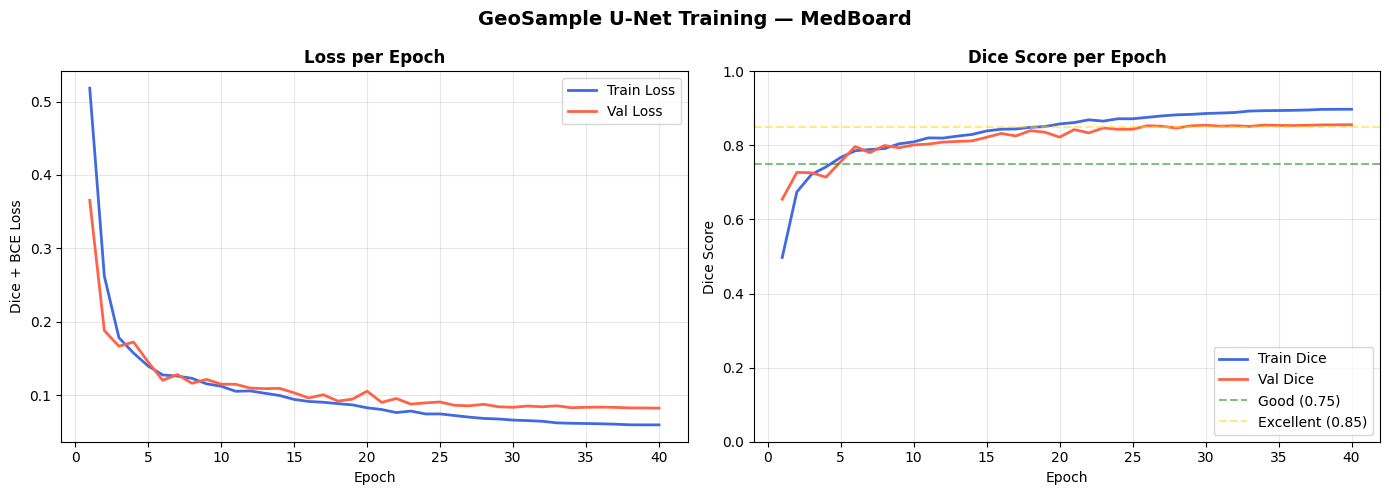

Plot saved to /content/drive/MyDrive/medboard/weights/geosample_training_curves_2.png


In [7]:
import matplotlib.pyplot as plt

epochs_ran = range(1, len(history['train_loss']) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# ── Loss curve ───────────────────────────────────────────────────────
ax1.plot(epochs_ran, history['train_loss'], label='Train Loss', color='royalblue', linewidth=2)
ax1.plot(epochs_ran, history['val_loss'],   label='Val Loss',   color='tomato',    linewidth=2)
ax1.set_title('Loss per Epoch', fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Dice + BCE Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# ── Dice score curve ─────────────────────────────────────────────────
ax2.plot(epochs_ran, history['train_dice'], label='Train Dice', color='royalblue', linewidth=2)
ax2.plot(epochs_ran, history['val_dice'],   label='Val Dice',   color='tomato',    linewidth=2)
ax2.axhline(0.75, color='green', linestyle='--', alpha=0.5, label='Good (0.75)')
ax2.axhline(0.85, color='gold',  linestyle='--', alpha=0.5, label='Excellent (0.85)')
ax2.set_title('Dice Score per Epoch', fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Dice Score')
ax2.set_ylim([0, 1])
ax2.legend(loc='lower right')
ax2.grid(True, alpha=0.3)

plt.suptitle('GeoSample U-Net Training — MedBoard', fontsize=14, fontweight='bold')
plt.tight_layout()

# Save plot
plot_path = f'{WEIGHTS_DIR}/geosample_training_curves_2.png'
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Plot saved to {plot_path}')

## Cell 8 — Evaluate on Test Set (Dice + IoU)

In [8]:
from modules.seg_trainer import validate_one_epoch, DiceBCELoss
from torch.cuda.amp import autocast
import numpy as np

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Safeguard: reload model if session disconnected
if 'model' not in locals():
    from modules.geosample_unet import build_geosample_unet
    import yaml
    with open(CONFIG_PATH) as f:
        cfg = yaml.safe_load(f)
    model = build_geosample_unet(cfg['segmentation'])
    model.load_state_dict(torch.load(FINAL_PATH, map_location=device))
    print(f'Model reloaded from: {FINAL_PATH}')

model = model.to(device)
model.eval()

# ── Overall Test Loss & Dice ─────────────────────────────────────────
criterion = DiceBCELoss()
test_loss, test_dice = validate_one_epoch(model, test_loader, criterion, device)

print('=' * 65)
print('          GeoSample U-Net — Test Set Evaluation')
print('=' * 65)
print(f'  Test Loss (Dice+BCE):  {test_loss:.4f}')
print(f'  Test Dice Score:       {test_dice:.4f}  ({test_dice*100:.2f}%)')
print('-' * 65)

          GeoSample U-Net — Test Set Evaluation
  Test Loss (Dice+BCE):  0.0784
  Test Dice Score:       0.8646  (86.46%)
-----------------------------------------------------------------


## Cell 9 — Per-Sample Evaluation (Dice + IoU Breakdown)

In [9]:
# ── Per-sample evaluation ────────────────────────────────────────────
all_dice_scores = []
all_iou_scores  = []

model.eval()
with torch.no_grad():
    for images, masks in test_loader:
        images = images.to(device, non_blocking=True)
        masks  = masks.to(device, non_blocking=True)

        with autocast():
            logits = model(images)

        # Per-sample metrics
        probs = torch.sigmoid(logits)
        pred_bin = (probs > 0.5).float()

        for i in range(images.shape[0]):
            p = pred_bin[i].view(-1)
            t = masks[i].view(-1)
            inter = (p * t).sum()
            dice = (2.0 * inter + 1.0) / (p.sum() + t.sum() + 1.0)
            union = p.sum() + t.sum() - inter
            iou  = (inter + 1.0) / (union + 1.0)
            all_dice_scores.append(dice.item())
            all_iou_scores.append(iou.item())

all_dice = np.array(all_dice_scores)
all_iou  = np.array(all_iou_scores)

# ── Print summary ────────────────────────────────────────────────────
print('=' * 65)
print('     GeoSample U-Net — Per-Sample Test Metrics')
print('=' * 65)
print(f'  Total test samples:    {len(all_dice)}')
print(f'')
print(f'  Dice Score:')
print(f'    Mean:   {all_dice.mean():.4f}  ({all_dice.mean()*100:.2f}%)')
print(f'    Median: {np.median(all_dice):.4f}  ({np.median(all_dice)*100:.2f}%)')
print(f'    Std:    {all_dice.std():.4f}')
print(f'    Min:    {all_dice.min():.4f}  ({all_dice.min()*100:.2f}%)')
print(f'    Max:    {all_dice.max():.4f}  ({all_dice.max()*100:.2f}%)')
print(f'')
print(f'  IoU Score:')
print(f'    Mean:   {all_iou.mean():.4f}  ({all_iou.mean()*100:.2f}%)')
print(f'    Median: {np.median(all_iou):.4f}  ({np.median(all_iou)*100:.2f}%)')
print(f'    Std:    {all_iou.std():.4f}')
print(f'    Min:    {all_iou.min():.4f}  ({all_iou.min()*100:.2f}%)')
print(f'    Max:    {all_iou.max():.4f}  ({all_iou.max()*100:.2f}%)')
print('-' * 65)

# ── Rating distribution ──────────────────────────────────────────────
excellent = (all_dice >= 0.85).sum()
good      = ((all_dice >= 0.75) & (all_dice < 0.85)).sum()
fair      = (all_dice < 0.75).sum()
print(f'  Rating Distribution:')
print(f'    Excellent (>=0.85): {excellent:4d}  ({excellent/len(all_dice)*100:.1f}%)')
print(f'    Good (0.75-0.85):   {good:4d}  ({good/len(all_dice)*100:.1f}%)')
print(f'    Fair/Poor (<0.75):  {fair:4d}  ({fair/len(all_dice)*100:.1f}%)')
print('=' * 65)

/tmp/ipykernel_700/4187917754.py:11: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


     GeoSample U-Net — Per-Sample Test Metrics
  Total test samples:    860

  Dice Score:
    Mean:   0.8641  (86.41%)
    Median: 0.9346  (93.46%)
    Std:    0.1836
    Min:    0.0003  (0.03%)
    Max:    0.9904  (99.04%)

  IoU Score:
    Mean:   0.7938  (79.38%)
    Median: 0.8774  (87.74%)
    Std:    0.2079
    Min:    0.0003  (0.03%)
    Max:    0.9810  (98.10%)
-----------------------------------------------------------------
  Rating Distribution:
    Excellent (>=0.85):  646  (75.1%)
    Good (0.75-0.85):     85  (9.9%)
    Fair/Poor (<0.75):   129  (15.0%)


## Cell 10 — Visualize Predictions (Random Samples)

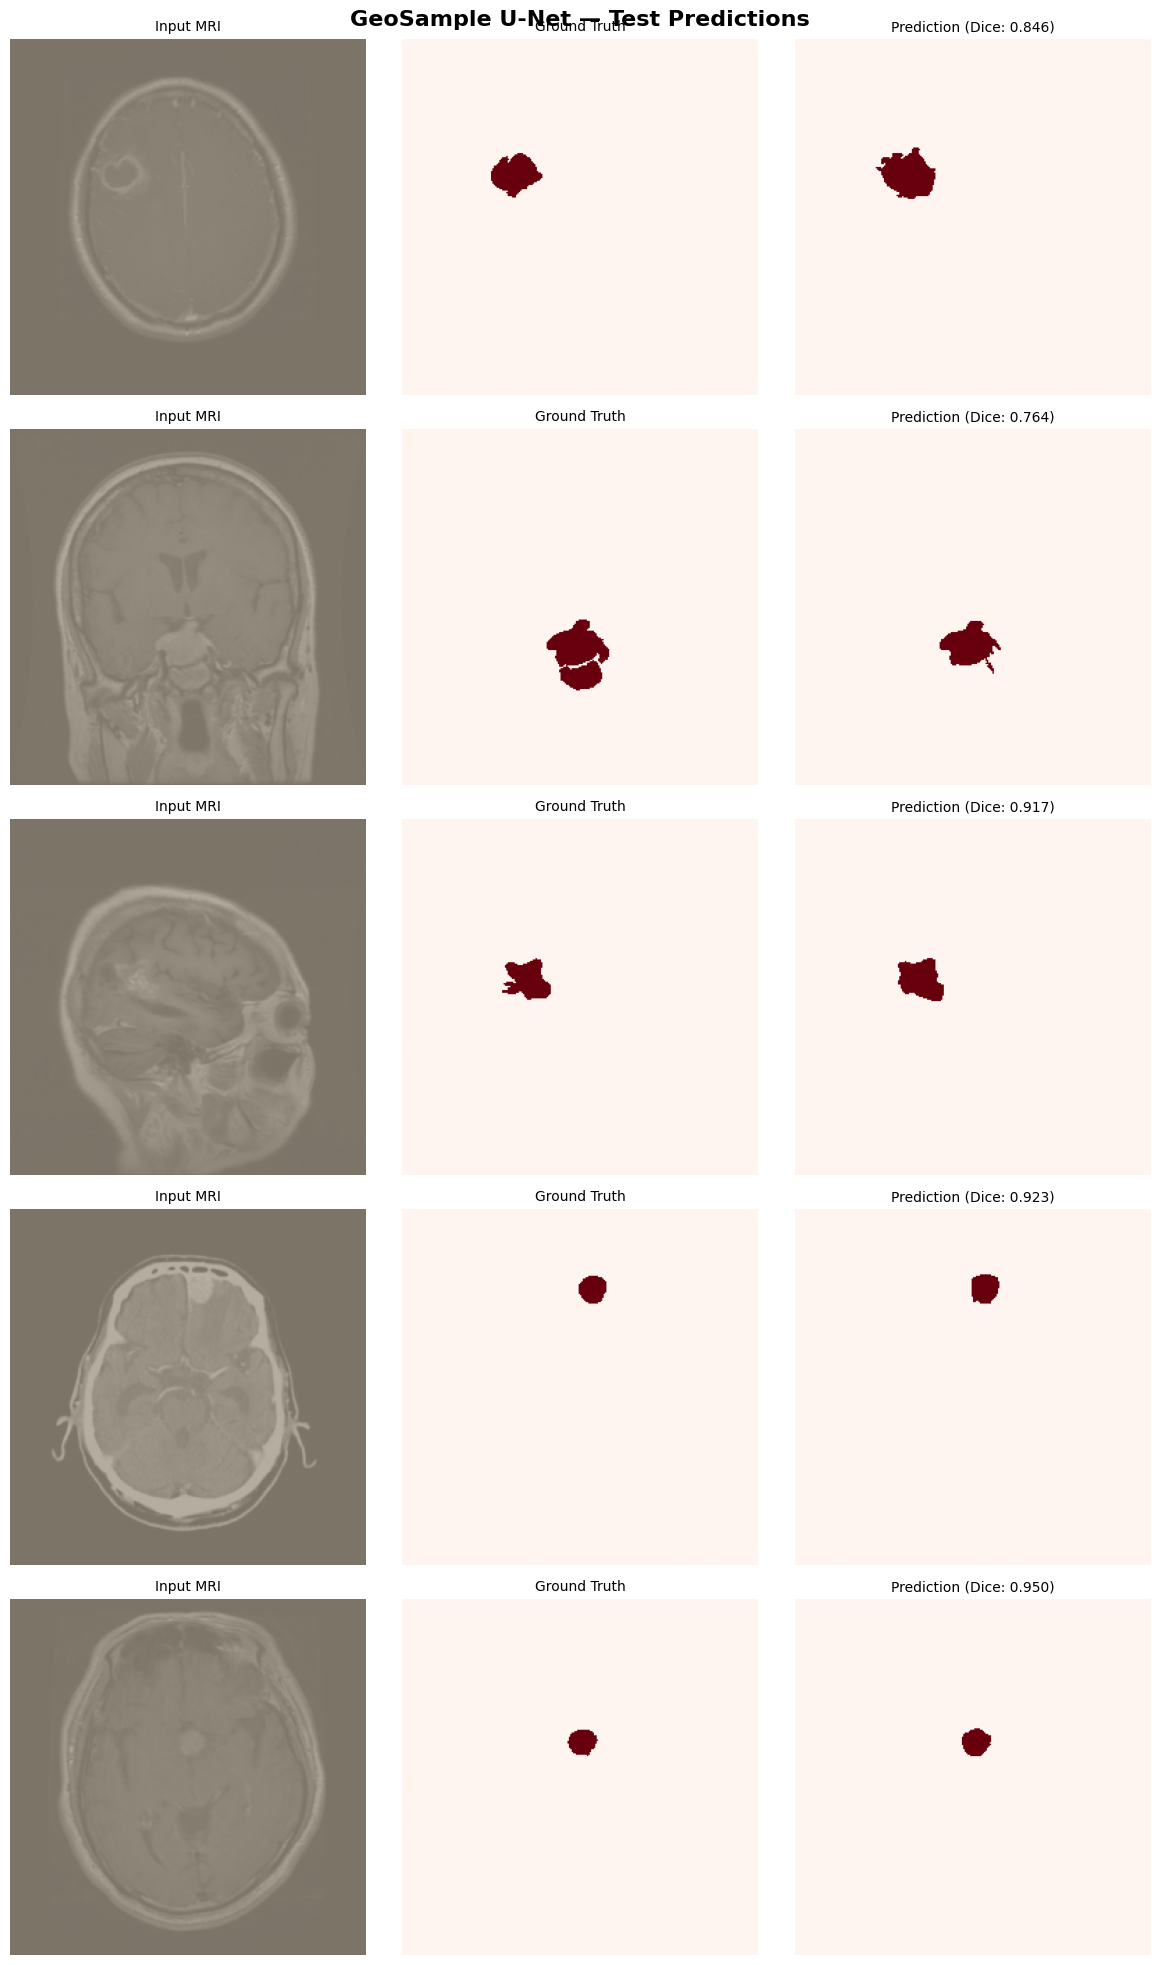

Visualization saved to /content/drive/MyDrive/medboard/weights/geosample_predictions_2.png


In [10]:
import random
import matplotlib.pyplot as plt

# ── Pick 5 random test samples ───────────────────────────────────────
test_dataset = test_loader.dataset
indices = random.sample(range(len(test_dataset)), 5)

fig, axes = plt.subplots(5, 3, figsize=(12, 20))
fig.suptitle('GeoSample U-Net — Test Predictions', fontsize=16, fontweight='bold')

for row, idx in enumerate(indices):
    img_tensor, mask_tensor = test_dataset[idx]
    img_input = img_tensor.unsqueeze(0).to(device)

    with torch.no_grad():
        logits = model(img_input)
        pred = torch.sigmoid(logits).squeeze().cpu().numpy()

    # Convert image for display (denormalize from ImageNet stats)
    img_display = img_tensor.permute(1, 2, 0).numpy()
    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])
    img_display = (img_display * std + mean).clip(0, 1)

    mask_np = mask_tensor.squeeze().numpy()
    pred_bin = (pred > 0.5).astype(float)

    # Compute sample dice
    inter = (pred_bin * mask_np).sum()
    sample_dice = (2 * inter + 1) / (pred_bin.sum() + mask_np.sum() + 1)

    # Plot: Input | Ground Truth | Prediction
    axes[row, 0].imshow(img_display)
    axes[row, 0].set_title('Input MRI', fontsize=10)
    axes[row, 0].axis('off')

    axes[row, 1].imshow(mask_np, cmap='Reds', vmin=0, vmax=1)
    axes[row, 1].set_title('Ground Truth', fontsize=10)
    axes[row, 1].axis('off')

    axes[row, 2].imshow(pred_bin, cmap='Reds', vmin=0, vmax=1)
    axes[row, 2].set_title(f'Prediction (Dice: {sample_dice:.3f})', fontsize=10)
    axes[row, 2].axis('off')

plt.tight_layout()

# Save
vis_path = f'{WEIGHTS_DIR}/geosample_predictions_2.png'
plt.savefig(vis_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Visualization saved to {vis_path}')

## Cell 11 — Save Metrics JSON

In [11]:
import json
import numpy as np

rating = 'Excellent (>=0.85)' if all_dice.mean() >= 0.85 else ('Good (0.75-0.85)' if all_dice.mean() >= 0.75 else 'Fair (<0.75)')

metrics = {
    'model': 'GeoSampleUNet',
    'architecture': 'GeoSample U-Net (Geometry-Guided Sampling with Consensus Skip Alignment)',
    'dataset': 'BRISC 2025 (Kaggle)',
    'parameters': int(count_parameters(model)),
    'input_shape': [3, 256, 256],
    'output_shape': [256, 256, 1],
    'test_samples': len(all_dice),
    'training': {
        'epochs_ran': len(history['train_loss']),
        'best_val_dice': round(float(max(history['val_dice'])), 4),
        'final_train_dice': round(float(history['train_dice'][-1]), 4),
        'final_train_loss': round(float(history['train_loss'][-1]), 4),
        'batch_size': BATCH_SIZE,
        'learning_rate': 2e-4,
        'lr_scheduler': 'cosine',
    },
    'metrics': {
        'test_loss_dice_bce': round(float(test_loss), 4),
        'test_dice_score': round(float(all_dice.mean()), 4),
        'test_dice_percentage': round(float(all_dice.mean()) * 100, 2),
        'test_median_dice': round(float(np.median(all_dice)), 4),
        'test_median_dice_percentage': round(float(np.median(all_dice)) * 100, 2),
        'test_iou_score': round(float(all_iou.mean()), 4),
        'test_iou_percentage': round(float(all_iou.mean()) * 100, 2),
        'test_dice_std': round(float(all_dice.std()), 4),
        'test_iou_std': round(float(all_iou.std()), 4),
        'benchmark_rating': rating,
    },
}

metrics_path = f'{WEIGHTS_DIR}/geosample_metrics_2.json'
with open(metrics_path, 'w') as f:
    json.dump(metrics, f, indent=2)

print(f'Metrics saved to: {metrics_path}')
print(json.dumps(metrics, indent=2))


Metrics saved to: /content/drive/MyDrive/medboard/weights/geosample_metrics_2.json
{
  "model": "GeoSampleUNet",
  "architecture": "GeoSample U-Net (Geometry-Guided Sampling with Consensus Skip Alignment)",
  "dataset": "BRISC 2025 (Kaggle)",
  "parameters": 4841497,
  "input_shape": [
    3,
    256,
    256
  ],
  "output_shape": [
    256,
    256,
    1
  ],
  "test_samples": 860,
  "training": {
    "epochs_ran": 40,
    "best_val_dice": 0.8559,
    "final_train_dice": 0.8977,
    "final_train_loss": 0.0596,
    "batch_size": 8,
    "learning_rate": 0.0002,
    "lr_scheduler": "cosine"
  },
  "metrics": {
    "test_loss_dice_bce": 0.0784,
    "test_dice_score": 0.8641,
    "test_dice_percentage": 86.41,
    "test_median_dice": 0.9346,
    "test_median_dice_percentage": 93.46,
    "test_iou_score": 0.7938,
    "test_iou_percentage": 79.38,
    "test_dice_std": 0.1836,
    "test_iou_std": 0.2079,
    "benchmark_rating": "Excellent (>=0.85)"
  }
}
